In [21]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [23]:

file_path = '/content/drive/MyDrive/house_price_data.csv'

# Load only 1000 random rows
data = pd.read_csv(file_path, skiprows=lambda i: i>0 and np.random.rand() > 0.001, nrows=1000)

In [24]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

drive.mount('/content/drive', force_remount=True)

# Load the data without skipping rows
file_path = '/content/drive/MyDrive/house_price_data.csv'
data = pd.read_csv(file_path, skiprows=lambda i: i>0 and np.random.rand() > 0.001, nrows=1000)

# Define the correct headers
headers = ["Transaction ID", "Price", "Date", "Postcode", "Property Type", "New Build", "Tenure", "PAON", "SAON", "Street", "Locality", "Town", "District", "County", "Record Status","Unnamed 16",	"Unnamed 17",	"Unnamed 18","Unnamed 19"]

if len(headers) != len(data.columns):
    print(f"Warning: Number of headers ({len(headers)}) does not match the number of columns in the data ({len(data.columns)}). The data might be loaded incorrectly.")
else:
    # Assign the headers to the DataFrame columns
    data.columns = headers

data.head()

Mounted at /content/drive


,Transaction ID,Price,Date,Postcode,Property Type,New Build,Tenure,PAON,SAON,Street,Locality,Town,District,County,Record Status,Unnamed 16,Unnamed 17,Unnamed 18,Unnamed 19
0,\{29DFF729-5925-4243-9672-9DC50CE82CAC\},485000,08/06/2004 00:00,B96 6PA,D,N,F,WOODLANDS VIEW,NaN,SAMBOURNE LANE,SAMBOURNE,REDDITCH,STRATFORD-ON-AVON,WARWICKSHIRE,A,C\,NaN,NaN,NaN
1,\{2ACACE8D-334A-295E-E063-4804A8C0B0EB\},135000,19/12/2014 00:00,SE20 8DL,F,N,L,142,NaN,ANERLEY ROAD,NaN,LONDON,BROMLEY,GREATER LONDON,A,A\,NaN,NaN,NaN
2,\{2ACACE8C-B667-295E-E063-4804A8C0B0EB\},725000,29/09/2023 00:00,TQ6 0PS,D,Y,F,11,NaN,JUBILEE ROAD,STOKE FLEMING,DARTMOUTH,SOUTH HAMS,DEVON,A,A\,NaN,NaN,NaN
3,\{2ACACE8C-8BCF-295E-E063-4804A8C0B0EB\},505000,28/11/2023 00:00,NW3 2AZ,F,Y,L,NOOR INAYAT KHAN HOUSE,FLAT 13,MAITLAND PARK VILLAS,NaN,LONDON,CAMDEN,GREATER LONDON,A,A\,NaN,NaN,NaN
4,\{2ACACE8D-8AC3-295E-E063-4804A8C0B0EB\},1710000,26/03/2024 00:00,SG1 2FP,O,N,F,GATEWAY 1000,UNIT 13,ARLINGTON BUSINESS PARK,NaN,STEVENAGE,STEVENAGE,HERTFORDSHIRE,B,A\,NaN,NaN,NaN


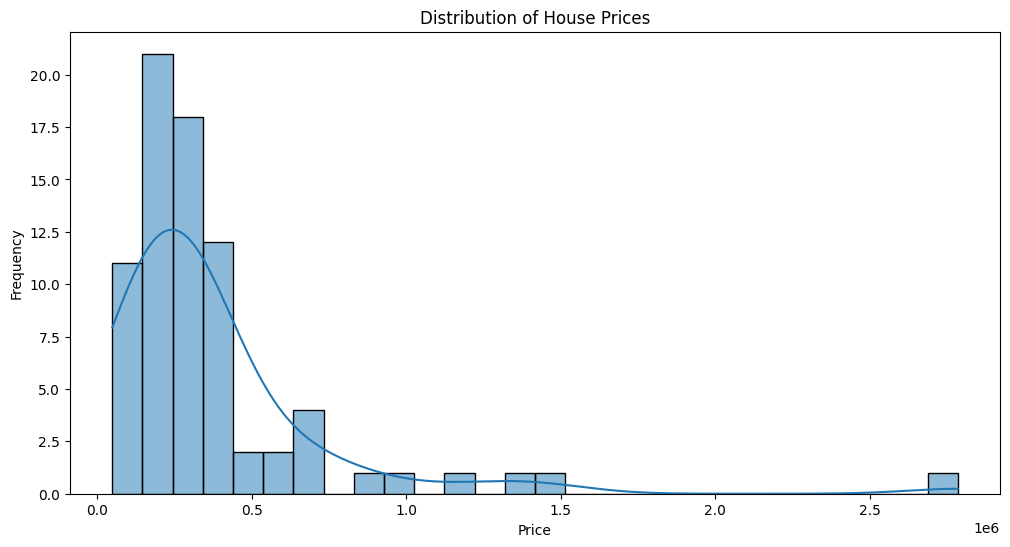

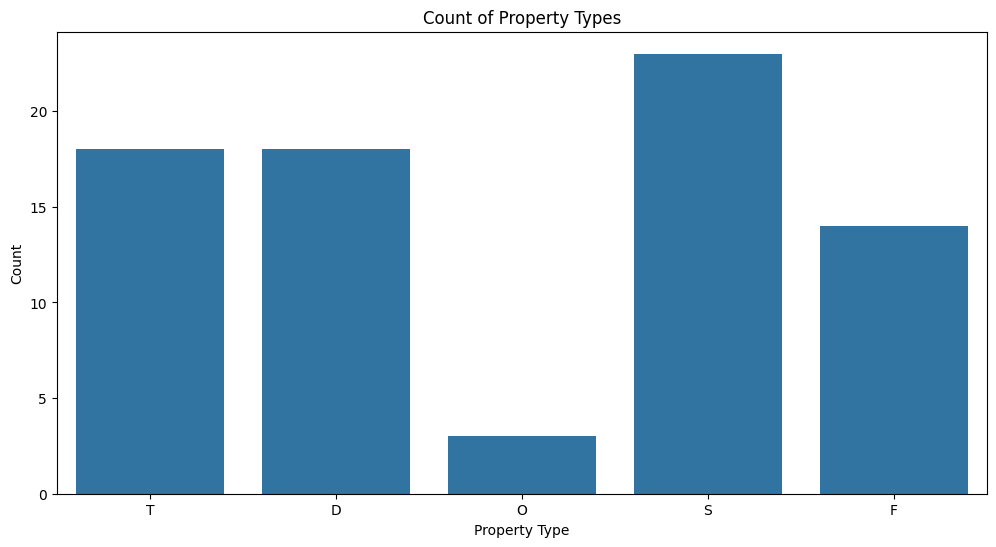

In [ ]:


import matplotlib.pyplot as plt
# Create visualizations
plt.figure(figsize=(12, 6))
sns.histplot(data['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='Property Type', data=data)
plt.title('Count of Property Types')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.show()




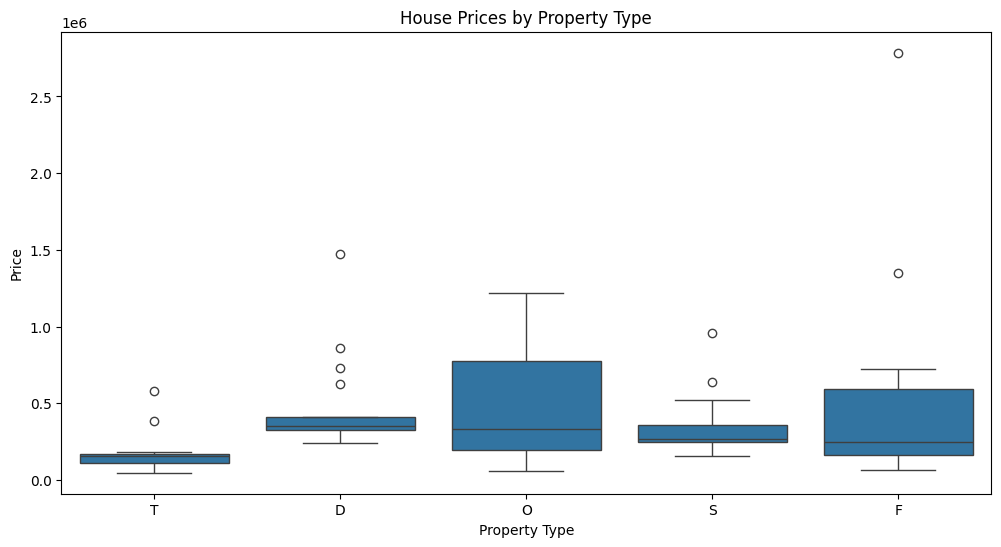

In [ ]:


# Additional visualizations

# Box plot of Price by Property Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='Property Type', y='Price', data=data)
plt.title('House Prices by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Price')
plt.show()


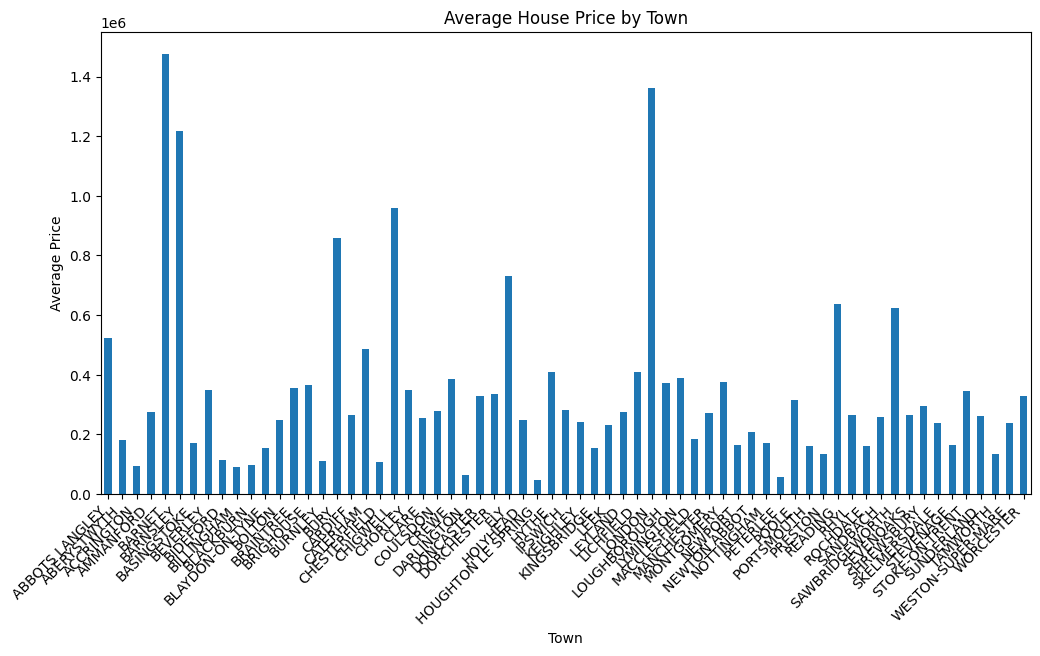

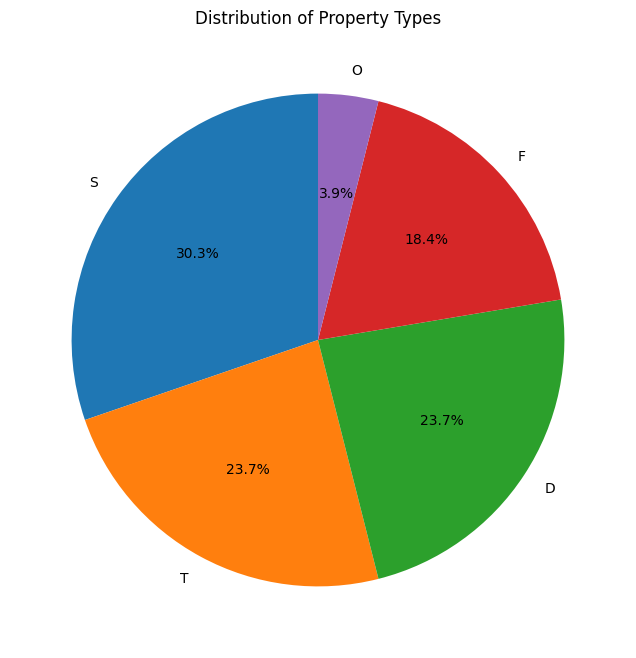

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
# Bar plot of average price by town
plt.figure(figsize=(12, 6))
data.groupby('Town')['Price'].mean().plot(kind='bar')
plt.title('Average House Price by Town')
plt.xlabel('Town')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.show()

# Create a pie chart of property types
property_type_counts = data['Property Type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(property_type_counts, labels=property_type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Property Types')
plt.show()



<Figure size 1500x800 with 0 Axes>

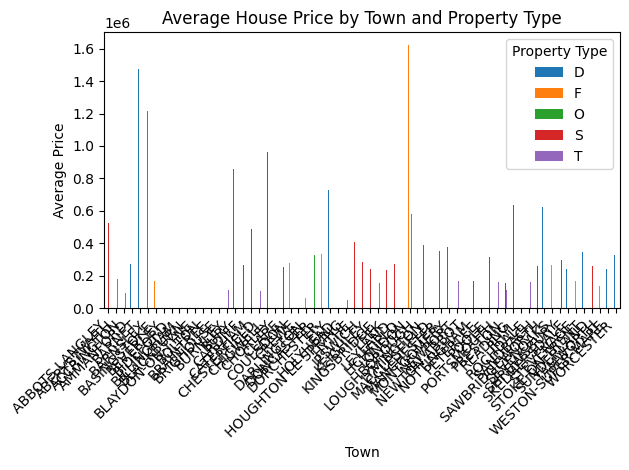

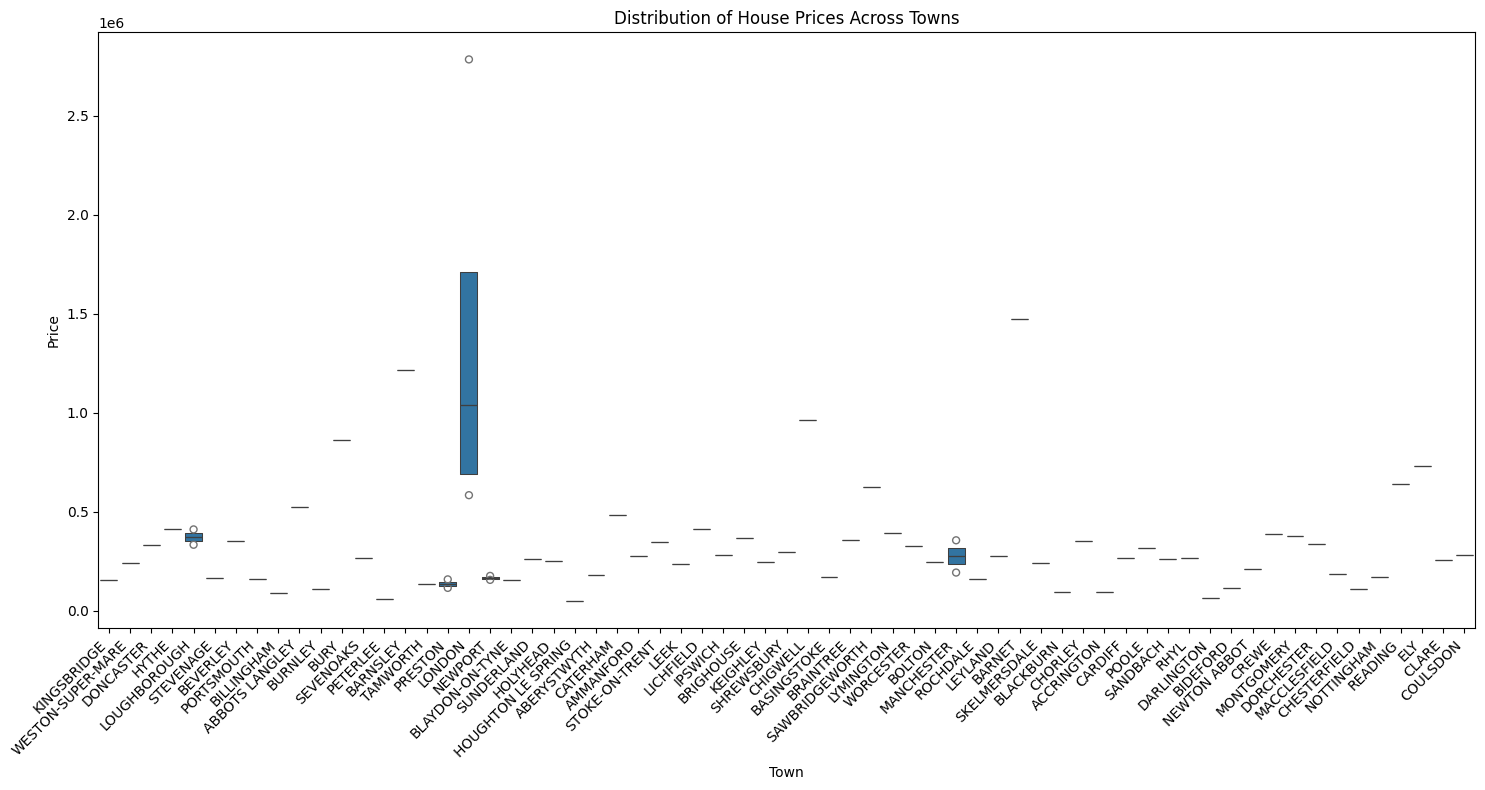

In [ ]:


import matplotlib.pyplot as plt




# Create a grouped bar chart of average price by town and property type
plt.figure(figsize=(15, 8))
data.groupby(['Town', 'Property Type'])['Price'].mean().unstack().plot(kind='bar')
plt.title('Average House Price by Town and Property Type')
plt.xlabel('Town')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Property Type')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Create a boxenplot to show the distribution of prices across different towns
plt.figure(figsize=(15, 8))
sns.boxenplot(x='Town', y='Price', data=data)
plt.title('Distribution of House Prices Across Towns')
plt.xlabel('Town')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()





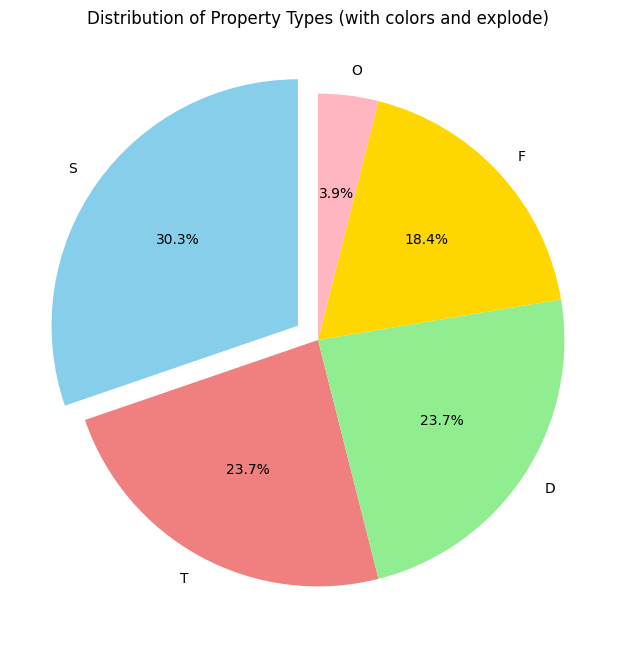

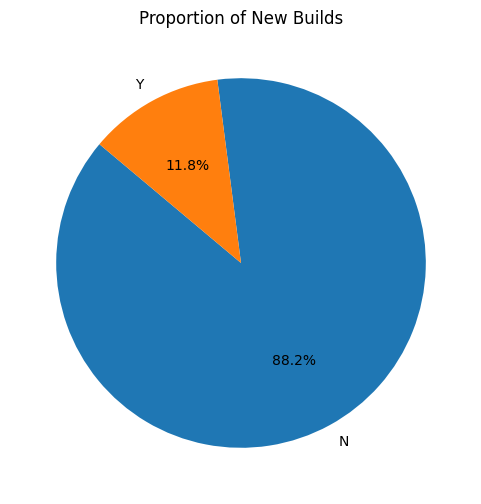

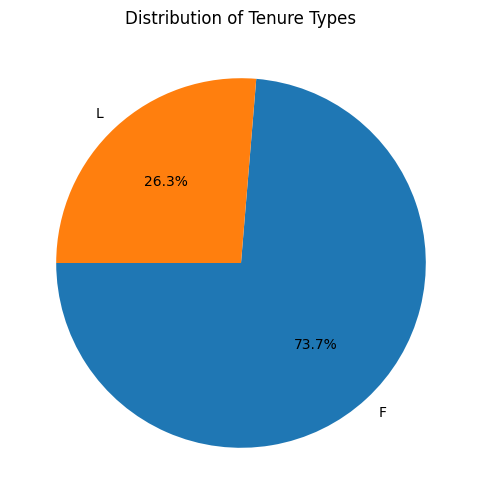

In [ ]:


import matplotlib.pyplot as plt
# Create a pie chart of property types with different colors and explode the largest slice
property_type_counts = data['Property Type'].value_counts()
plt.figure(figsize=(8, 8))
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink']  # Example colors
explode = [0.1 if i == property_type_counts.index[0] else 0 for i in property_type_counts.index] # Explode the largest slice
plt.pie(property_type_counts, labels=property_type_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode)
plt.title('Distribution of Property Types (with colors and explode)')
plt.show()


# Create a pie chart showing the proportion of new builds
new_build_counts = data['New Build'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(new_build_counts, labels=new_build_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of New Builds')
plt.show()

# Create a pie chart showing the distribution of tenure types
tenure_counts = data['Tenure'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(tenure_counts, labels=tenure_counts.index, autopct='%1.1f%%', startangle=180)
plt.title('Distribution of Tenure Types')
plt.show()


In [ ]:

import numpy as np
# Data preprocessing and cleaning
# Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].mean())

# Drop irrelevant columns
data = data.drop(["Transaction ID", "Date", "PAON", "SAON", "Street", "Locality", "Town", "District", "County", "Record Status", "Unnamed 16", "Unnamed 17", "Unnamed 18", "Unnamed 19"], axis=1)

# Convert categorical features to numerical using Label Encoding
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

# Feature scaling
scaler = StandardScaler()
numerical_cols = data.select_dtypes(include=np.number).columns
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])


In [ ]:
import numpy as np
# Calculate descriptive statistics for numerical features
numerical_stats = data.describe()
print("Descriptive Statistics for Numerical Features:\n", numerical_stats)

# Define categorical columns based on the columns available in your preprocessed data
categorical_cols = ['Postcode', 'Property Type', 'New Build', 'Tenure']

# Select these columns from the original dataframe 'data'
categorical_data = data[categorical_cols]

# Calculate descriptive statistics for categorical features
categorical_stats = categorical_data.astype('object').describe()  # Convert to object type for categorical stats
print("\nDescriptive Statistics for Categorical Features:\n", categorical_stats)


# Group data by remaining categorical columns and calculate summary statistics for 'Price'
property_type_stats = data.groupby('Property Type')['Price'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
print("\nSummary Statistics for Price by Property Type:\n", property_type_stats)

# Calculate skewness and kurtosis
skewness = data.skew()
kurtosis = data.kurtosis()

print("\nSkewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)

# Calculate the range for numerical features
numerical_cols = data.select_dtypes(include=np.number).columns
ranges = data[numerical_cols].max() - data[numerical_cols].min()
print("\nRanges of Numerical Features:\n", ranges)

# Calculate percentiles (e.g., 10th, 25th, 50th, 75th, 90th)
percentiles = data[numerical_cols].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print("\nPercentiles of Numerical Features:\n", percentiles)

Descriptive Statistics for Numerical Features:
               Price      Postcode  Property Type     New Build        Tenure
count  7.600000e+01  7.600000e+01   7.600000e+01  7.600000e+01  7.600000e+01
mean   6.902373e-17 -1.168656e-17   1.197872e-16  1.022574e-17  1.168656e-17
std    1.006645e+00  1.006645e+00   1.006645e+00  1.006645e+00  1.006645e+00
min   -8.253891e-01 -1.666111e+00  -1.376773e+00 -3.665083e-01 -5.976143e-01
25%   -5.248653e-01 -8.561708e-01  -7.268675e-01 -3.665083e-01 -5.976143e-01
50%   -2.706743e-01 -6.004003e-04   5.729426e-01 -3.665083e-01 -5.976143e-01
75%    1.818649e-02  8.549700e-01   5.729426e-01 -3.665083e-01  1.673320e+00
max    6.171176e+00  1.710540e+00   1.222848e+00  2.728451e+00  1.673320e+00

Descriptive Statistics for Categorical Features:
          Postcode  Property Type  New Build     Tenure
count   76.000000      76.000000  76.000000  76.000000
unique  75.000000       5.000000   2.000000   2.000000
top     -1.666111       0.572943  -0.366508

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.6920 - mae: 0.6055 - val_loss: 3.2631 - val_mae: 0.9872
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step - loss: 0.6105 - mae: 0.5659 - val_loss: 3.2791 - val_mae: 0.9716
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step - loss: 0.5003 - mae: 0.5058 - val_loss: 3.3090 - val_mae: 0.9619
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step - loss: 0.5549 - mae: 0.5023 - val_loss: 3.3137 - val_mae: 0.9643
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - loss: 0.6379 - mae: 0.5499 - val_loss: 3.3251 - val_mae: 0.9671
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 0.5074 - mae: 0.4876 - val_loss: 3.3332 - val_mae: 0.9725
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step - loss: 0.4963 - mae: 0.4707 - val_loss: 3.3272 - val_mae: 0.9789
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 444ms/step - loss: 0.5337 - mae: 0.4907 - val_loss: 3.3264 - val_mae: 0.9859
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step - loss: 0.4954 - mae: 0.4

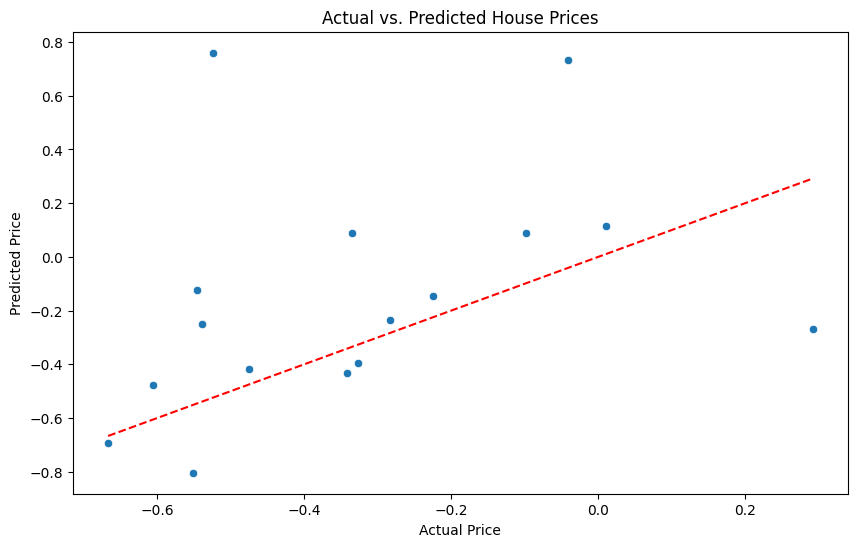

In [ ]:


# Split data into training and testing sets
X = data.drop('Price', axis=1)
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regression model (Neural Network)
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error on test data: {mae}")


import pandas as pd
import matplotlib.pyplot as plt
# Predict prices on the test set
y_pred = model.predict(X_test)

# Create a DataFrame for actual vs. predicted prices
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred.flatten()})

# Display the first few rows of the DataFrame
print(comparison_df.head(15))

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_df)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Add diagonal line
plt.show()




Training Linear Regression...
Mean Squared Error: 0.337004973745479
R-squared: -4.179445965668044
    Actual Price  Predicted Price
4      -0.098137         0.471108
35     -0.326913        -0.461967
10     -0.666899        -0.411395
0      -0.551866        -0.058860
45     -0.539085        -0.047173
47     -0.545475        -0.089072
65      0.010518         0.674794
53     -0.040608         0.449322
50     -0.334581         0.752841
28      0.291709        -0.357903
67     -0.475177        -0.210724
70     -0.342250         0.265751
18     -0.605548         0.196375
12     -0.524386         0.434959
58     -0.283456        -0.331887


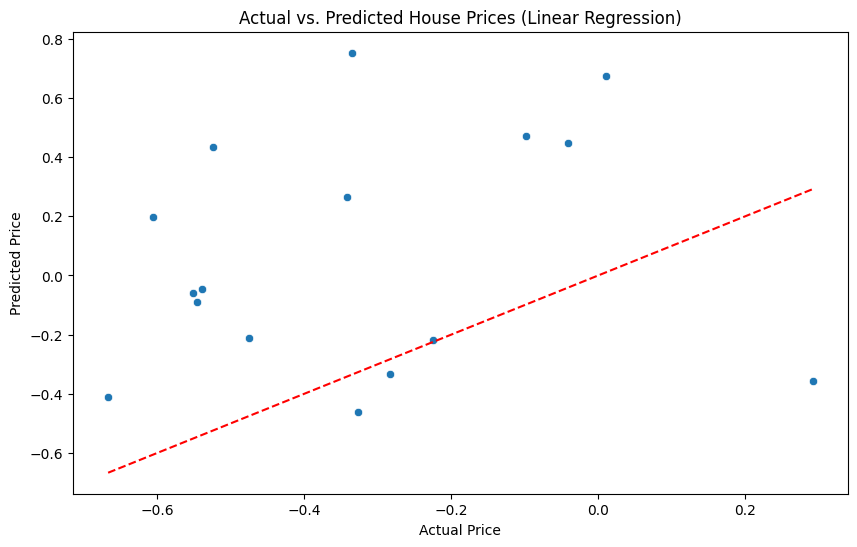


Training Decision Tree...
Mean Squared Error: 0.6370665002413523
R-squared: -8.791106279129796
    Actual Price  Predicted Price
4      -0.098137         0.099988
35     -0.326913        -0.142860
10     -0.666899        -0.702687
0      -0.551866        -0.718025
45     -0.539085        -0.551866
47     -0.545475        -0.245111
65      0.010518         2.502900
53     -0.040608        -0.270674
50     -0.334581        -0.110906
28      0.291709        -0.296237
67     -0.475177        -0.672012
70     -0.342250        -0.569760
18     -0.605548        -0.797270
12     -0.524386        -0.781932
58     -0.283456         0.099988


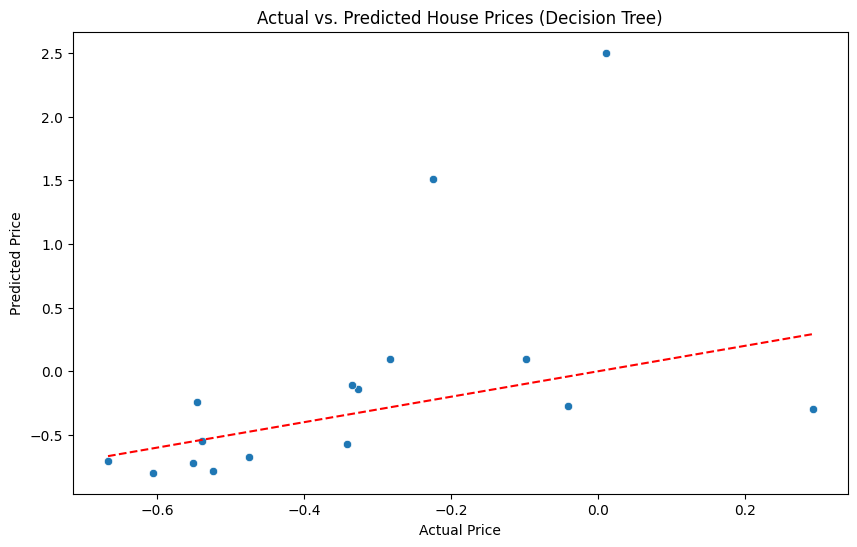


Training Random Forest...
Mean Squared Error: 0.23789585360758747
R-squared: -2.6562330387075015
    Actual Price  Predicted Price
4      -0.098137         0.169544
35     -0.326913        -0.203150
10     -0.666899        -0.644966
0      -0.551866        -0.614658
45     -0.539085        -0.534841
47     -0.545475        -0.092769
65      0.010518         0.775311
53     -0.040608        -0.080183
50     -0.334581         0.371389
28      0.291709        -0.203955
67     -0.475177        -0.603668
70     -0.342250        -0.227805
18     -0.605548        -0.358304
12     -0.524386         0.292722
58     -0.283456         0.036323


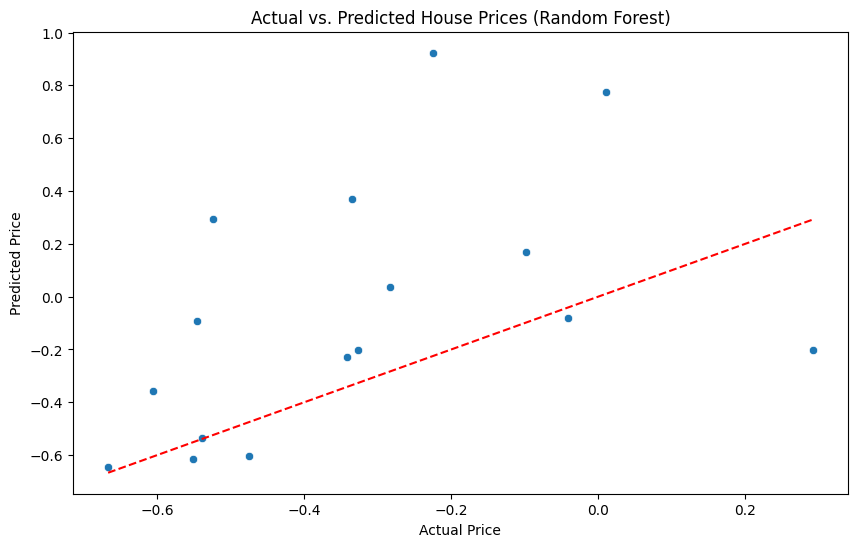

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Define a list of regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}


for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error: {mse}")
    print(f"R-squared: {r2}")

    # Create a DataFrame for actual vs. predicted prices
    comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})

    # Display the first few rows of the DataFrame
    print(comparison_df.head(15))

    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_df)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'Actual vs. Predicted House Prices ({name})')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Add diagonal line
    plt.show()


    Actual Price  Predicted Price
4      -0.098137         0.169544
35     -0.326913        -0.203150
10     -0.666899        -0.644966
0      -0.551866        -0.614658
45     -0.539085        -0.534841
47     -0.545475        -0.092769
65      0.010518         0.775311
53     -0.040608        -0.080183
50     -0.334581         0.371389
28      0.291709        -0.203955
67     -0.475177        -0.603668
70     -0.342250        -0.227805
18     -0.605548        -0.358304
12     -0.524386         0.292722
58     -0.283456         0.036323
Root Mean Squared Logarithmic Error (RMSLE): 0.4987712339492174
Mean Absolute Error (MAE): 0.35716024887157116
Root Mean Squared Error (RMSE): 0.48774568538080115


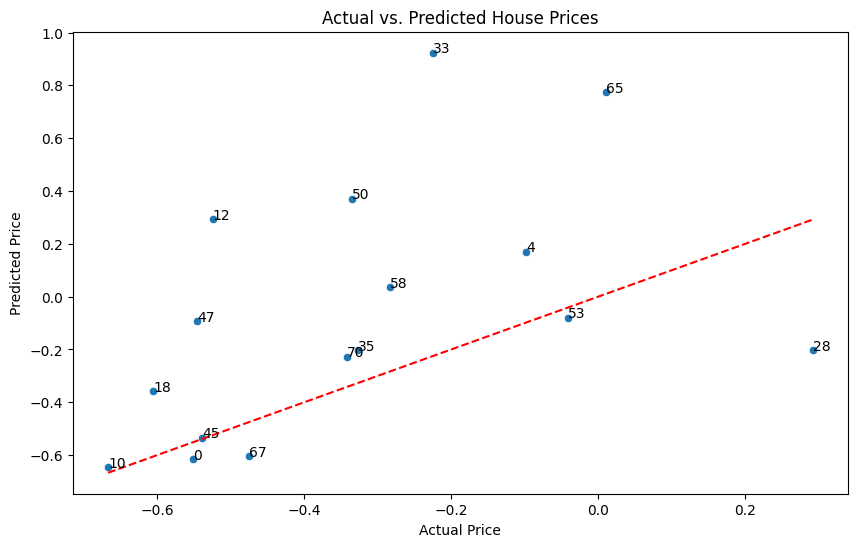

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Predict prices on the test set
y_pred = model.predict(X_test)

# Create a DataFrame for actual vs. predicted prices
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred.flatten()})

# Display the first few rows of the DataFrame
print(comparison_df.head(15))

# Calculate additional evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_log_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

try:
    rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    print(f"Root Mean Squared Logarithmic Error (RMSLE): {rmsle}")
except ValueError:
    print("RMSLE calculation failed. Check for negative or zero values in predictions or actuals.")


print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_df)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Add diagonal line

# Annotate points on the scatter plot using the DataFrame index
for index, row in comparison_df.iterrows():
    plt.annotate(index, (row['Actual Price'], row['Predicted Price'])) # Use DataFrame index for annotation


plt.show()

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.0 MB/s eta 0:00:00


In [ ]:


import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=512, step=32),
                    activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1)))

    for i in range(hp.Int('n_layers', 1, 3)):
        model.add(Dense(units=hp.Int(f'units_{i+2}', min_value=32, max_value=512, step=32),
                        activation='relu'))
        model.add(Dropout(hp.Float(f'dropout_{i+2}', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(1))  # Output layer

    model.compile(optimizer=keras.optimizers.Adam(
        hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='mse', metrics=['mae'])
    return model

tuner = kt.Hyperband(build_model,
                     objective='val_mae',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='house_price_prediction')

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[stop_early])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is {best_hps.get('units_1')}, in the second layer is {best_hps.get('units_2') if best_hps.get('n_layers')>0 else 'N/A'},
and the optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")


model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2)

eval_result = model.evaluate(X_test, y_test)
print("[test loss, test accuracy]:", eval_result)


Reloading Tuner from my_dir/house_price_prediction/tuner0.json

The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is 352, in the second layer is 320,
and the optimal learning rate for the optimizer is 0.0001.

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - loss: 0.7182 - mae: 0.5710 - val_loss: 3.5417 - val_mae: 0.9840
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.6612 - mae: 0.5618 - val_loss: 3.5353 - val_mae: 0.9793
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.6022 - mae: 0.5206 - val_loss: 3.5199 - val_mae: 0.9754
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.7152 - mae: 0.5655 - val_loss: 3.5008 - val_mae: 0.9728
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.5969 - mae: 0.5335 - val_loss: 3.4872 - val_mae: 0.9696
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.5674 - mae: 0.5126 - val_loss: 3.4746 - val_mae: 0.9671
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.5124 - mae: 0.4828 - val_loss: 3.4641 - val_mae: 0.9653
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.6303 - mae: 0.5365 - val_loss: 3.4531 - val_mae: 0.9639
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.6269 - mae: 0.5220 - val_loss: